Generamos una secuencia de 10.000 números aleatorios con distribución uniforme en [1,100]:

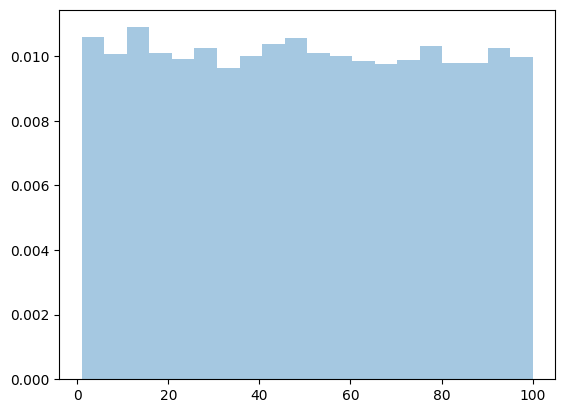

In [43]:
import random
import numpy as np
import matplotlib.pyplot as plt
a=1
b=100
N=10000
np.random.seed(0)
DataPop=list(np.random.uniform(a,b,N))
plt.hist(DataPop, bins=20, density=True, histtype='stepfilled', alpha=0.4)
plt.show()

Extraemos aleatoriamente muestras de 100 elementos de dicha población. Evaluamos su promedio, y vemos que el histograma de dichos valores se asemeja a una distribución Gaussiana (normal).

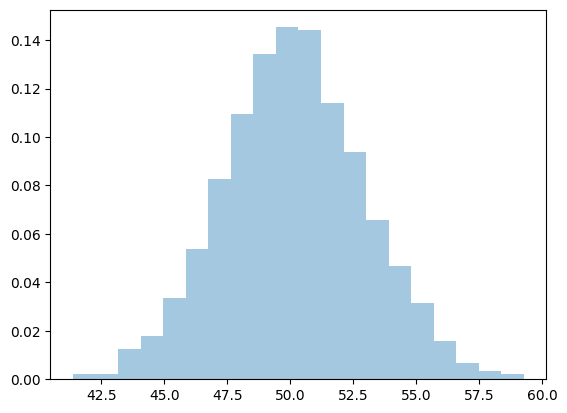

In [45]:
SamplesMeans = []
for i in range(0,1000):
    DataExtracted = random.sample(DataPop,k=100)
    DataExtractedMean = np.mean(DataExtracted)
    SamplesMeans.append(DataExtractedMean)
plt.figure()
plt.hist(SamplesMeans, bins=20, density=True, histtype='stepfilled', alpha=0.4)
plt.show()


Algo interesante para saber es que la elección aleatoria de la muestra puede realizarse con cualquier función de distribución como base.

Por ejemplo, usemos la gaussiana. Vamos a elegir teniendo en cuenta la probabilidad de una distribución gaussiana con media 50.5 y desviación estándar 15:

In [ ]:
import numpy as np
from scipy.stats import norm

population = np.linspace(1, 100, 10000)
# Compute normal distribution weights centered in the interval
mu = 50.5      # mean (center of [1, 100])
sigma = 15     # standard deviation (adjust to control spread)

weights = norm.pdf(population, loc=mu, scale=sigma)
weights = weights / weights.sum()   # normalize so they sum to 1
# Lo que hicimos antes con random.uniform es equivalente a usar weights uniformes (todos iguales)

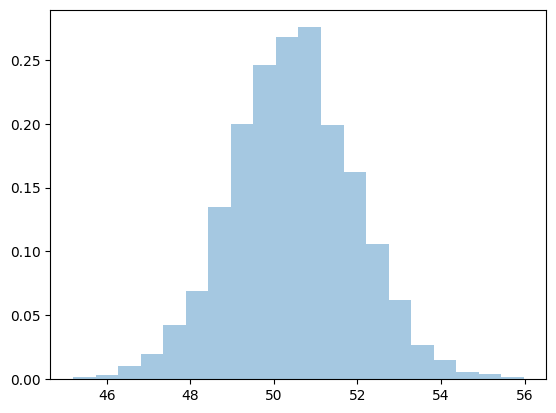

In [54]:
SamplesMeans = []

for i in range(0,5000):
    DataExtracted = np.random.choice(population, size=100, replace=False, p=weights)
    DataExtractedMean = np.mean(DataExtracted)
    SamplesMeans.append(DataExtractedMean)
plt.figure()
plt.hist(SamplesMeans, bins=20, density=True, histtype='stepfilled', alpha=0.4)
plt.show()

También podemos elegir con repetición y no debería haber problema, gracias al teorema central del límite!

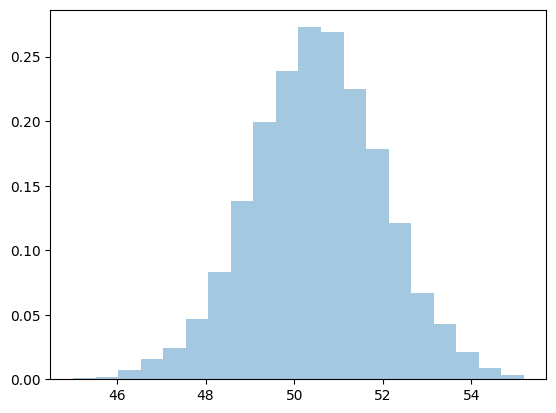

In [55]:
SamplesMeans = []

for i in range(0,5000):
    DataExtracted = np.random.choice(population, size=100, replace=True, p=weights)
    DataExtractedMean = np.mean(DataExtracted)
    SamplesMeans.append(DataExtractedMean)
plt.figure()
plt.hist(SamplesMeans, bins=20, density=True, histtype='stepfilled', alpha=0.4)
plt.show()